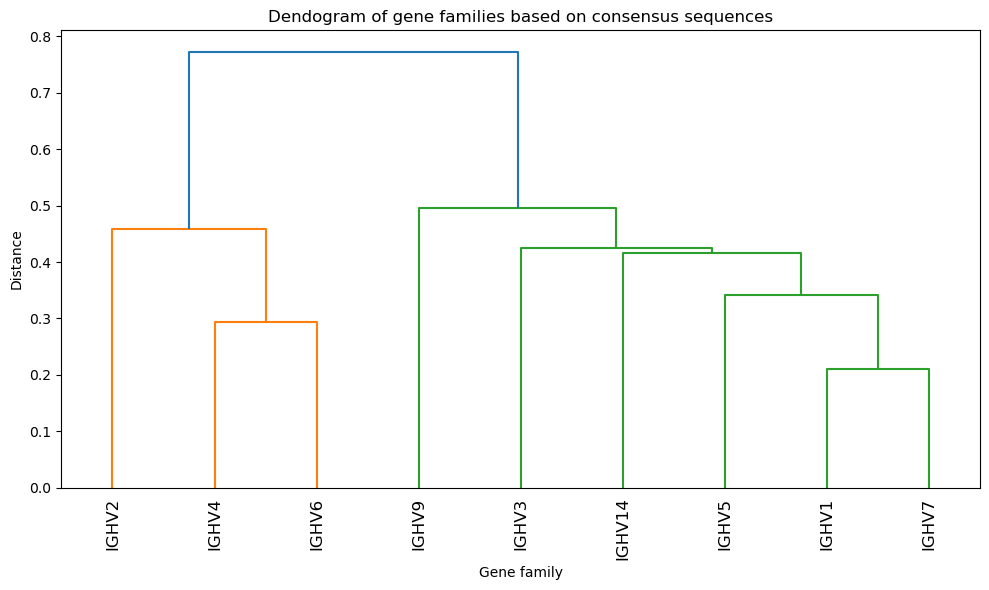

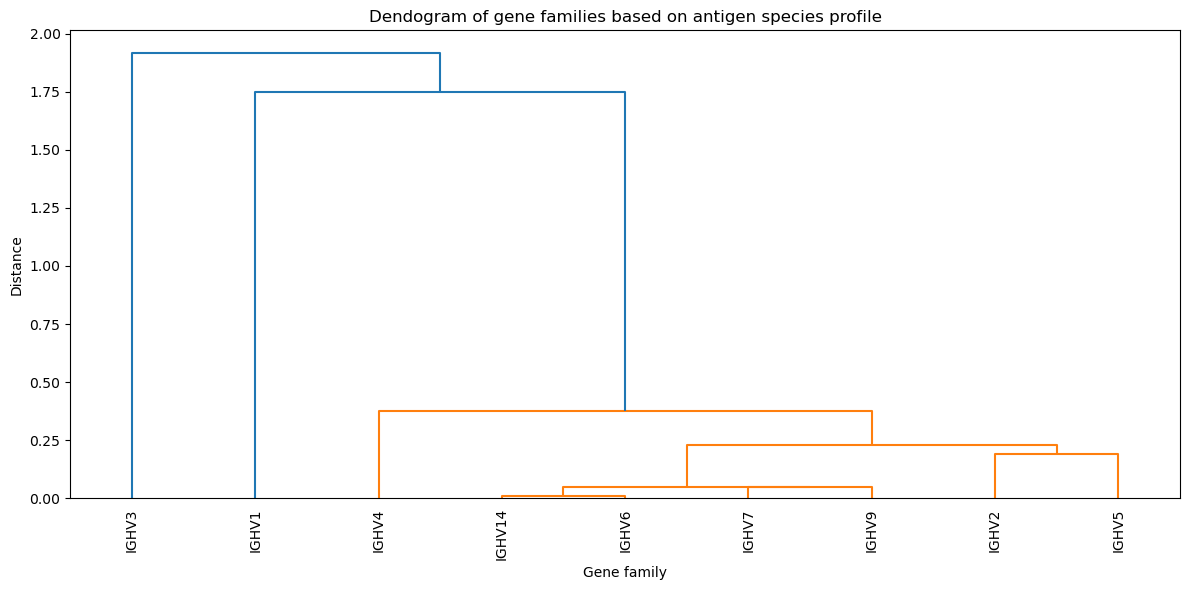

Cophenetische Korrelation erstes Cluster: 0.774
Cophenetische Korrelation zweites Cluster: 0.928
Cophenetische Korrelation zwischen den beiden Dendrogrammen: -0.188


In [10]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ------------------------
# Erster Datensatz: Distanzmatrix einlesen und Linkage berechnen
# ------------------------

# Pfad zur Distanzmatrix (achte auf korrekten Pfad)
file_path = "msa_consensus_output/distance_matrix.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

n = int(lines[0].strip())

labels_1 = []
matrix = []

for line in lines[1:]:
    parts = line.strip().split()
    label = parts[0]
    values = list(map(float, parts[1:]))
    labels_1.append(label)
    matrix.append(values)

df = pd.DataFrame(matrix, index=labels_1, columns=labels_1)

# Sicherstellen, dass quadratisch
assert df.shape[0] == df.shape[1], "Distance matrix muss quadratisch sein!"

# Distanzmatrix als float
matrix_float = df.values.astype(float)

# Kondensierte Distanzmatrix (für linkage)
condensed_dist_1 = squareform(matrix_float)

# Linkage berechnen (Ward)
Z1 = linkage(condensed_dist_1, method='ward')

# Dendrogramm zeichnen
plt.figure(figsize=(10, 6))
dendrogram(Z1, labels=labels_1, leaf_rotation=90)
plt.title("Dendogram of gene families based on consensus sequences")
plt.xlabel("Gene family")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# ------------------------
# Zweiter Datensatz: CSV einlesen und Linkage berechnen
# ------------------------

df2 = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

df2["antigen_species"] = df2["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df2_exploded = df2.explode("antigen_species")

relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df2_filtered = df2_exploded[df2_exploded["antigen_species"].isin(relevant_species)]

pivot = df2_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

pivot_scaled = StandardScaler().fit_transform(pivot)

Z2 = linkage(pivot_scaled, method="single", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(
    Z2,
    labels=pivot.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)
plt.title("Dendogram of gene families based on antigen species profile")
plt.xlabel("Gene family")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# ------------------------
# Cophenetische Korrelation zur Bewertung der Ähnlichkeit der Cluster
# ------------------------

# Cophenetische Distanz für erstes Clustering (basierend auf der ersten Distanzmatrix)
coph_corr_1, coph_dist_1 = cophenet(Z1, condensed_dist_1)

# Cophenetische Distanz für zweites Clustering (basierend auf pivot_scaled)
condensed_dist_2 = pdist(pivot_scaled, metric='euclidean')
coph_corr_2, coph_dist_2 = cophenet(Z2, condensed_dist_2)

print(f"Cophenetische Korrelation erstes Cluster: {coph_corr_1:.3f}")
print(f"Cophenetische Korrelation zweites Cluster: {coph_corr_2:.3f}")

# ------------------------
# Vergleich der beiden Dendrogramme via cophenetischer Distanz
# ------------------------

# Für Vergleich brauchen wir die cophenetischen Distanzen (Arrays) beider Cluster
# Beide Arrays haben Länge n*(n-1)/2, n = Anzahl Clusterpunkte

# Jetzt kann man z.B. die Korrelation zwischen den beiden cophenetischen Distanzarrays berechnen:
correlation_between_clusters = np.corrcoef(coph_dist_1, coph_dist_2)[0,1]
print(f"Cophenetische Korrelation zwischen den beiden Dendrogrammen: {correlation_between_clusters:.3f}")